In [2]:
#!pip install torchvision
#!pip install torch

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
import os
from PIL import Image
from IPython.display import display


import warnings
warnings.filterwarnings('ignore')

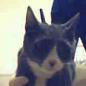

In [14]:
with Image.open('../CNN_project/CATS_DOGS/test/CAT/10107.jpg') as im:
    display(im)

### Create a list of file names

In [24]:
path = '../CNN_project/CATS_DOGS'

img_names = []

for folder, subfolders, filenames in os.walk(path):
    #print(folder)
    for img in filenames:
        img_names.append(folder+'/'+img)
        

#print(img_names)

### Create a DataFrame of image sizes(width,height)




In [16]:
img_sizes = []
rejected = []


for item in img_names:
    try:
        with Image.open(item) as img:
            img_sizes.append(img.size)
    except:
        rejected.append(item)

print(f"Images: {len(img_sizes)}")
print(f"Rejects: {len(rejected)}")

Images: 24998
Rejects: 3


In [19]:
df = pd.DataFrame(img_sizes)
df.head() #0 = width, 1 + height

,0,1
0,365,500
1,484,500
2,448,500
3,500,483
4,500,375


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24998 entries, 0 to 24997
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       24998 non-null  int64
 1   1       24998 non-null  int64
dtypes: int64(2)
memory usage: 390.7 KB


In [23]:
df.describe()

,0,1
count,24998.000000,24998.000000
mean,404.473518,361.020242
std,108.953650,96.940787
min,42.000000,33.000000
25%,323.000000,302.000000
50%,448.000000,375.000000
75%,500.000000,421.000000
max,500.000000,500.000000


### Transformations

(312, 270)


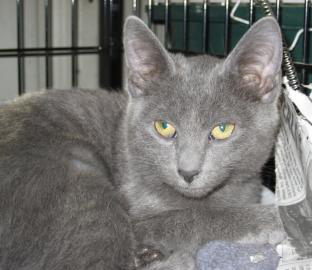

In [45]:
cat = Image.open('../CNN_project/CATS_DOGS/train/CAT/5466.jpg')
print(cat.size)
display(cat)

In [38]:
r,g,b = cat.getpixel((0,0))

print(r,g,b)

14 31 100


### transforms.ToTensor()

torch.Size([3, 500, 375])


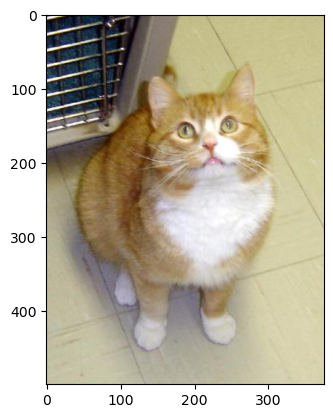

In [44]:
transform = transforms.Compose([
    transforms.ToTensor()
]
)

im = transform(cat)

print(im.shape) #color channel, height, weight
plt.imshow(np.transpose(im.numpy(),(1,2,0))) #reorder the axes to H,W,C)
plt.show()

* Pytorch format -->> (C,H,W)
* Matplotlib -->> (H,W,C)

In [37]:
im

tensor([[[0.0549, 0.0784, 0.0980,  ..., 0.7647, 0.7647, 0.7647],
         [0.0980, 0.1216, 0.1412,  ..., 0.7686, 0.7686, 0.7686],
         [0.1373, 0.1490, 0.1608,  ..., 0.7725, 0.7725, 0.7725],
         ...,
         [0.7922, 0.7882, 0.7804,  ..., 0.8431, 0.8431, 0.8471],
         [0.7922, 0.7882, 0.7804,  ..., 0.8431, 0.8471, 0.8471],
         [0.7961, 0.7922, 0.7843,  ..., 0.8471, 0.8471, 0.8471]],

        [[0.1216, 0.1451, 0.1569,  ..., 0.7412, 0.7412, 0.7412],
         [0.1373, 0.1647, 0.1765,  ..., 0.7451, 0.7451, 0.7451],
         [0.1451, 0.1490, 0.1647,  ..., 0.7490, 0.7490, 0.7490],
         ...,
         [0.7686, 0.7647, 0.7569,  ..., 0.8275, 0.8275, 0.8314],
         [0.7686, 0.7647, 0.7569,  ..., 0.8275, 0.8314, 0.8314],
         [0.7725, 0.7686, 0.7608,  ..., 0.8314, 0.8314, 0.8314]],

        [[0.3922, 0.4157, 0.4275,  ..., 0.5373, 0.5373, 0.5373],
         [0.4078, 0.4235, 0.4392,  ..., 0.5412, 0.5412, 0.5412],
         [0.3765, 0.3843, 0.3882,  ..., 0.5451, 0.5451, 0.

In [39]:
14/255, 31/255,100/255

(0.054901960784313725, 0.12156862745098039, 0.39215686274509803)

In [40]:
im[:,0,0]

tensor([0.0549, 0.1216, 0.3922])

### transforms.resize()

torch.Size([3, 224, 258])


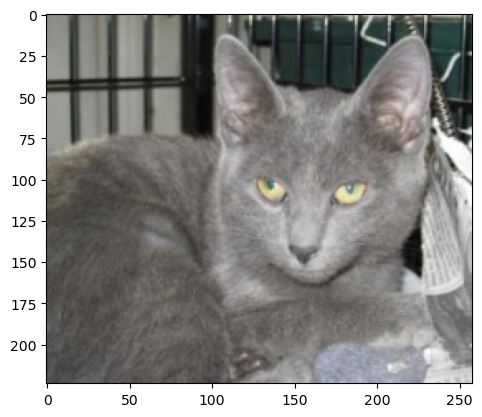

In [46]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor()
]
)

im = transform(cat)

print(im.shape) #color channel, height, weight
plt.imshow(np.transpose(im.numpy(),(1,2,0))) #reorder the axes to H,W,C)
plt.show()

torch.Size([3, 224, 224])


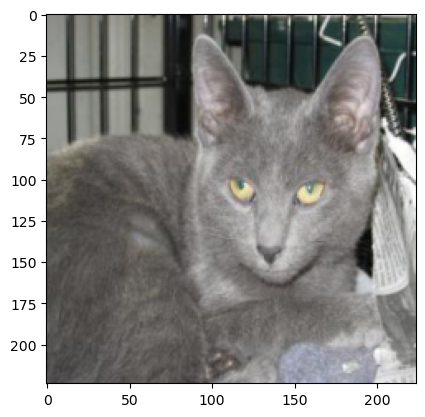

In [48]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
]
)

im = transform(cat)

print(im.shape) #color channel, height, weight
plt.imshow(np.transpose(im.numpy(),(1,2,0))) #reorder the axes to H,W,C)
plt.show()

### transforms.CenterCrop

torch.Size([3, 124, 124])


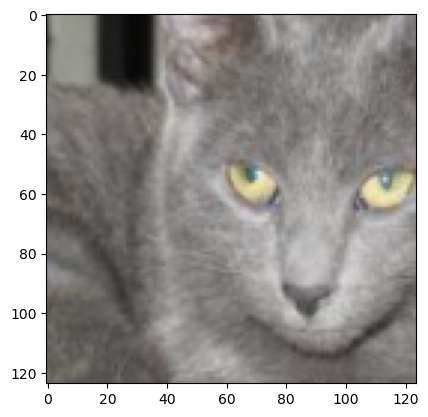

In [51]:
transform = transforms.Compose([
    transforms.Resize((224,244)),
    transforms.CenterCrop(124),
    transforms.ToTensor()
]
)

im = transform(cat)

print(im.shape) #color channel, height, weight
plt.imshow(np.transpose(im.numpy(),(1,2,0))) #reorder the axes to H,W,C)
plt.show()

### transforms.HorizontalFlip

torch.Size([3, 270, 312])


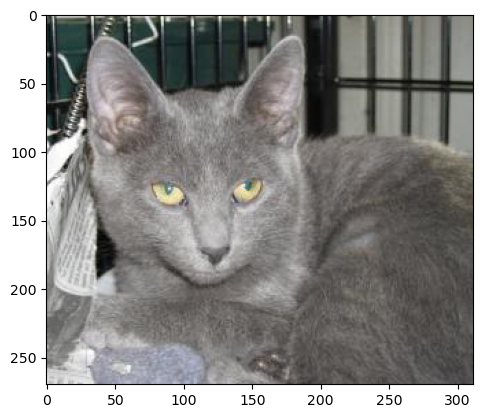

In [61]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    transforms.ToTensor()
]
)

im = transform(cat)

print(im.shape) #color channel, height, weight
plt.imshow(np.transpose(im.numpy(),(1,2,0))) #reorder the axes to H,W,C)
plt.show()

### tranforms.RandomRotation

torch.Size([3, 270, 312])


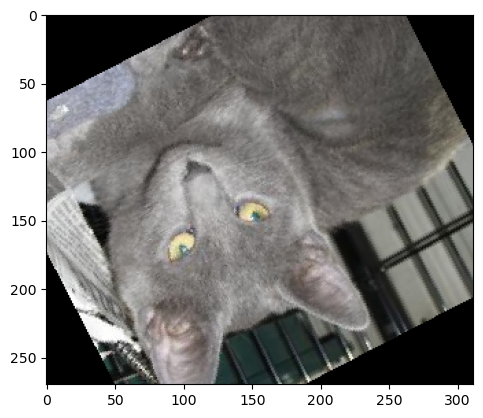

In [73]:
transform = transforms.Compose([
    transforms.RandomRotation((1,359)),
    transforms.ToTensor()
]
)

im = transform(cat)

print(im.shape) #color channel, height, weight
plt.imshow(np.transpose(im.numpy(),(1,2,0))) #reorder the axes to H,W,C)
plt.show()

### Putting it all together

torch.Size([3, 224, 224])


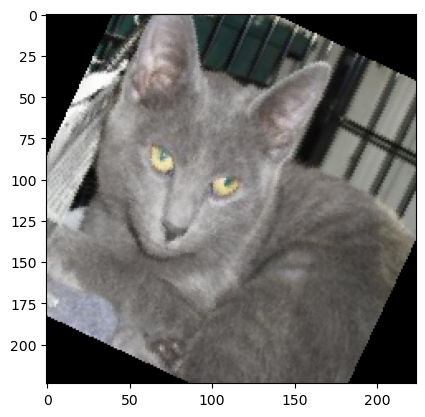

In [77]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.CenterCrop(224),
    transforms.ToTensor()
]
)

im = transform(cat)

print(im.shape) #color channel, height, weight
plt.imshow(np.transpose(im.numpy(),(1,2,0))) #reorder the axes to H,W,C)
plt.show()

### normalization


* mean = [0.485,0.456,.406]
* std = [0.229,.224,.225]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


torch.Size([3, 270, 312])


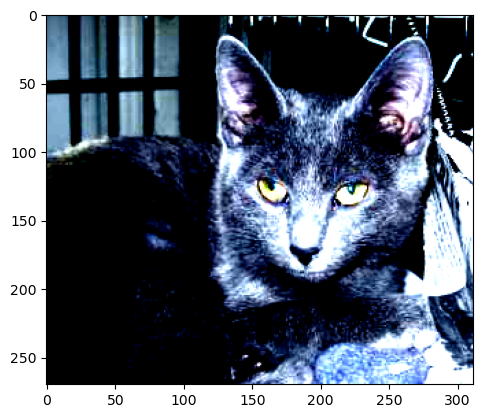

In [79]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,.406],
                        [0.229,.224,.225])
]
)

im = transform(cat)

print(im.shape) #color channel, height, weight
plt.imshow(np.transpose(im.numpy(),(1,2,0))) #reorder the axes to H,W,C)
plt.show()

In [80]:
im[:,0,0]

tensor([0.1768, 0.3277, 0.4439])

### De-normalize the images

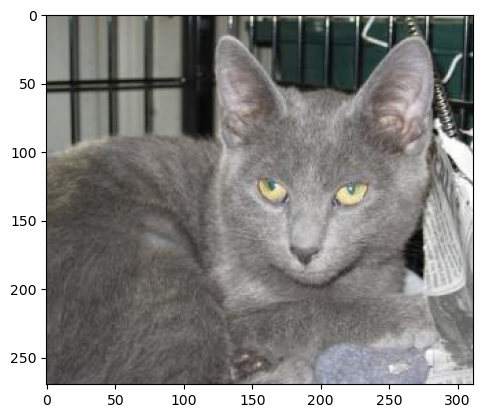

In [81]:
inv_normalize = transforms.Normalize(
    mean = [-0.485/0.229,-0.456/.224,-.406/0.225],
    std = [1/.229,1/.224,1/.225]
)

im_inv = inv_normalize(im)
plt.imshow(np.transpose(im_inv.numpy(),(1,2,0))) #reorder the axes to H,W,C)
plt.show()